MCS 320 Midterm Two Wednesday 29 July 2026.  Submit to gradescope by 3:40pm.

# Question 1

What is the problem of premature evaluation when defining SageMath function?

1. Illustrate your explanations with an example we have covered in the course.

2. Use the example to show how to fix this premature evaluation problem.

## answer to question 1

The problem with premature evaluation occurs when the expression which defines a SageMath function is evaluated symbolically, as in the example below.

In [1]:
f(x) = min(x, 1)
f

x |--> x

The function f which takes x as argument should return the minimum of x and 1.  Because of the premature evaluation, it will always return x.

A solution to this problem is to use a regular Python function.

In [2]:
g = lambda x: min(x, 1)

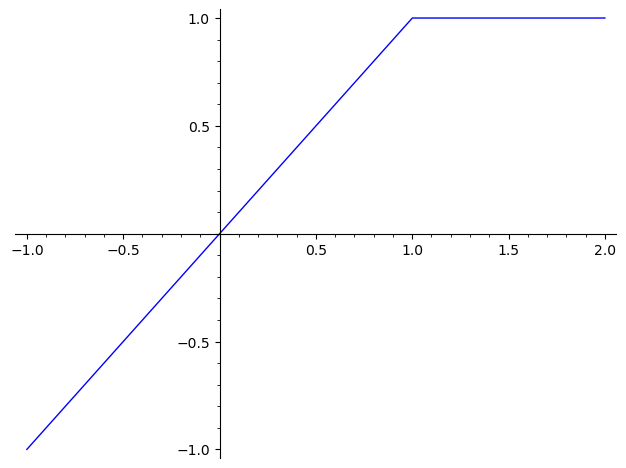

In [3]:
plot(g,(x, -1, 2))

# Question 2

Consider 
$\displaystyle f_k(x_1, x_2, \ldots, x_n) 
= x_k^2 + \sum_{j=1, j\not= k}^n (2j+1) x_j + (2n) x_k - 7$.

Define a function ``F`` which takes on input a list ``X`` of variables
and an index ``k`` in the range of ``X``.
``F(X, k)``  returns $f_k(x_1, x_2, \ldots, x_n)$.

Show that your function works for $n = 8$.

## answer to question 2

In [4]:
reset()

In [5]:
X = [var('x' + str(k)) for k in range(1, 9)]
X

[x1, x2, x3, x4, x5, x6, x7, x8]

In [6]:
F = lambda X, k: X[k-1]^2 + sum([(2*j+1)*X[j-1] for j in range(1, len(X)+1)]) - (2*k+1)*X[k-1] + 2*len(X)*X[k-1] - 7

In [7]:
[F(X, k) for k in range(1, 9)]

[x1^2 + 16*x1 + 5*x2 + 7*x3 + 9*x4 + 11*x5 + 13*x6 + 15*x7 + 17*x8 - 7,
 x2^2 + 3*x1 + 16*x2 + 7*x3 + 9*x4 + 11*x5 + 13*x6 + 15*x7 + 17*x8 - 7,
 x3^2 + 3*x1 + 5*x2 + 16*x3 + 9*x4 + 11*x5 + 13*x6 + 15*x7 + 17*x8 - 7,
 x4^2 + 3*x1 + 5*x2 + 7*x3 + 16*x4 + 11*x5 + 13*x6 + 15*x7 + 17*x8 - 7,
 x5^2 + 3*x1 + 5*x2 + 7*x3 + 9*x4 + 16*x5 + 13*x6 + 15*x7 + 17*x8 - 7,
 x6^2 + 3*x1 + 5*x2 + 7*x3 + 9*x4 + 11*x5 + 16*x6 + 15*x7 + 17*x8 - 7,
 x7^2 + 3*x1 + 5*x2 + 7*x3 + 9*x4 + 11*x5 + 13*x6 + 16*x7 + 17*x8 - 7,
 x8^2 + 3*x1 + 5*x2 + 7*x3 + 9*x4 + 11*x5 + 13*x6 + 15*x7 + 16*x8 - 7]

# Question 3

Let $C$ be the curve defined by $x^4 + x^3 y - y^2 = 0$
      and the point 
      $\displaystyle P = \left(1, \frac{1+\sqrt{5}}{2}\right)$ on $C$.

1. Compute the tangent line of $C$ at $P$.

2. Viewing $y$ in function of $x$, what is
   $\displaystyle y'(1) = \left. \frac{dy}{dx}\right|_{x=1}$?

## answer to question 3

In [8]:
reset()

In [9]:
x, y = var('x, y')
c = x^4 + x^3*y - y^2
show(c)

x^4 + x^3*y - y^2

The Taylor series of ``c`` at the point, truncated after the linear term, gives the tangent line.

In [10]:
t = taylor(c, (x, 1), (y, (1+sqrt(5))/2), 1)
t

1/2*(x - 1)*(3*sqrt(5) + 11) - 1/2*sqrt(5)*(2*y - sqrt(5) - 1)

The slope of the tangent line gives ``y'(1)``.

In [11]:
slope = -t.coefficient(x, 1)/t.coefficient(y,1)
slope

1/10*sqrt(5)*(3*sqrt(5) + 11)

# Question 4

The arc length of the curve $y = \exp(x)$ is defined by
the function $\displaystyle L(t) = \int_0^t \sqrt{1 + \exp(x)^2} dx$.

Define the function $L(t)$.  What is $L(1)$?  Compute $L'(1)$.

## answer to question 4

In [12]:
reset()

In [13]:
L(t) = integral(sqrt(1 + exp(x)^2), (x, 0, t), hold=True)
L

t |--> integrate(sqrt(e^(2*x) + 1), x, 0, t)

In [14]:
L(1)

-sqrt(2) + sqrt(e^2 + 1) + 1/2*log(sqrt(2) + 1) - 1/2*log(sqrt(2) - 1) - 1/2*log(sqrt(e^2 + 1) + 1) + 1/2*log(sqrt(e^2 + 1) - 1)

In [15]:
dL = diff(L, t)
dL

t |--> sqrt(e^(2*t) + 1)

In [16]:
dL(1)

sqrt(e^2 + 1)

# Question 5

Write an efficient recursive function to compute
$$
         q_0(x) = 1, ~~ q_1(x) = 1 - x, ~~ \mbox{for } n > 1:
         q_n(x) = (3x + 1) q_{n-1}(x) + 2x q_{n-2}(x).
$$
Make sure your function can compute $q_{100}(x)$.
      
Do *NOT* use ``cached_function``.

## answer to question 5

In [17]:
reset()

In [18]:
def q(n, x, D={}):
    """
    Returns p(x) using memoization.
    """
    if (n, x) in D:
        return D[(n, x)]
    else:
        if n == 0:
            result = 1
        elif n == 1:
            result = 1 - x
        else:
            result = expand((3*x+1)*q(n-1, x) + 2*x*q(n-2, x))
        D[(n,x)] = result
        return result

In [19]:
[q(k, x) for k in range(5)]

[1,
 -x + 1,
 -3*x^2 + 4*x + 1,
 -9*x^3 + 7*x^2 + 9*x + 1,
 -27*x^4 + 6*x^3 + 42*x^2 + 14*x + 1]

In [20]:
q(100, x)

-171792506910670443678820376588540424234035840667*x^100 - 9124090922588941342052904445480258087096570204314*x^99 - 237442695292311096933563659760413020428361092667078*x^98 - 4035305126984655900410697045075541732196360378283186*x^97 - 50362364053482234683930147950965222829604877515724567*x^96 - 492119542400891183376622595098023746641136829165676944*x^95 - 3919868034998104853647203324355141804502970087633638448*x^94 - 26163144656549100282703166874947384712932491221602343696*x^93 - 149277904426259247680404247888906973568803618318565133652*x^92 - 739096893864130684721373456042375517082830732825994655144*x^91 - 3212356213669662003892016371282556999939120583357848772408*x^90 - 12367431686208793479901640062948012240966016281250422520136*x^89 - 42474935590002117334777870399700977474800478819227118145172*x^88 - 130840562286065029505729614874359733093322663792162476169264*x^87 - 362943117642251180681481988408177979889547693113552573238608*x^86 - 90893187775870833519218259343304004022792002681240

# Question 6


Let $p = x ( y^2 - x z )^2 - y^5 = 0$ and $q = y^4 + y^3 z - x^2 z^2 = 0$
define two surfaces, \newline respectively called $P$ and $Q$.

1. Plot the two surfaces $P$ and $Q$, using the colors red and green,
   with a suitable range for $x$, $y$, and $z$ so the curve of 
   intersection $P \cap Q$ if visible.

2. Interpret the plot.  What can you state about the curve $P \cap Q$?

## answer to question 6

In [21]:
reset()

In [22]:
x, y, z = var('x, y, z')

In [23]:
p = x*(y^2 - x*z)^2 - y^5
show(p)

-y^5 + (y^2 - x*z)^2*x

In [24]:
pp = implicit_plot3d(p, (x, -1, 1), (y,-1,1), (z, -1, 1), color='red')

In [25]:
q = y^4 + y^3*z - x^2*z^2
show(q)

y^4 + y^3*z - x^2*z^2

In [26]:
qq = implicit_plot3d(q, (x, -1, 1), (y,-1,1), (z, -1, 1), color='green')

In [27]:
show(pp+qq)

Graphics3d Object

The curve of intersection breaks up in two lines.  Observe that the z-axis is one of those lines.

In [28]:
p(x=0, y=0)

0

In [29]:
q(x=0, y=0)

0

# Question 7

Compute a symbolic-numeric factorization of $p = x^4 - 2 x^2 + 999999/1000000$.

What is the accuracy of the factors and the corresponding roots?

Let $q$ be the expanded polynomial obtained by multiplying the
computed linear factors.

Compare the coefficients of $q$ with the coefficients of $p$.

## answer to question 7

In [30]:
reset()

In [31]:
p = x^4 - 2*x^2 + 999999/1000000
show(p)

x^4 - 2*x^2 + 999999/1000000

In [32]:
f = factor(QQbar[x](p))
show(f)

(x - 1.000499875062461?) * (x - 0.9994998749374609? + 0.?e-46*I) * (x + 0.9994998749374609? + 0.?e-46*I) * (x + 1.000499875062461?)

In [33]:
L = list(f)
L

[(x - 1.000499875062461?, 1),
 (x - 0.9994998749374609? + 0.?e-46*I, 1),
 (x + 0.9994998749374609? + 0.?e-46*I, 1),
 (x + 1.000499875062461?, 1)]

In [34]:
q = product( t for (t, m) in L )
q

x^4 + (-2.000000000000000? + 0.?e-45*I)*x^2 + 0.999999000000000? + 0.?e-45*I

In [35]:
cp = [p.coefficient(x, k) for k in range(5)]
cp

[999999/1000000, 0, -2, 0, 1]

In [36]:
cq = [SR(q).coefficient(x, k) for k in range(5)]
cq

[0.9999990000000000?, 0, -2.000000000000000?, 0, 1]

In [37]:
p - q

0.?e-35

Up to the working precision with which the factors of ``p`` are computed, both expressions are identical.

# Question 8

Find the points on the sphere $x^2 + y^2 + z^2 - 4 = 0$
closest to the point $P = (3, 1, -1)$.

1. Using Lagrange multipliers, set up a polynomial system.
2. Convert this polynomial into triangular form.
3. What are the closest points to $P$ on the sphere?

## answer to question 8

In [38]:
reset()

In [39]:
t(x, y, z) = (x - 3)^2 + (y - 1)^2 + (z + 1)^2
t

(x, y, z) |--> (x - 3)^2 + (y - 1)^2 + (z + 1)^2

In [40]:
c(x, y, z) = x^2 + y^2 + z^2 - 4
c

(x, y, z) |--> x^2 + y^2 + z^2 - 4

In [41]:
gt = t.gradient()
gt

(x, y, z) |--> (2*x - 6, 2*y - 2, 2*z + 2)

In [42]:
gc = c.gradient()
gc

(x, y, z) |--> (2*x, 2*y, 2*z)

In [43]:
L = var('L') # the lambda parameter

In [44]:
eqs = [gt(x,y,z)[k] - L*gc(x,y,z)[k] for k in range(3)]
eqs

[-2*L*x + 2*x - 6, -2*L*y + 2*y - 2, -2*L*z + 2*z + 2]

In [45]:
eqs.append(c(x,y,z))
eqs

[-2*L*x + 2*x - 6, -2*L*y + 2*y - 2, -2*L*z + 2*z + 2, x^2 + y^2 + z^2 - 4]

In [46]:
s = solve(eqs, (x, y, z, L), solution_dict=True)
s

[{x: 6/11*sqrt(11), y: 2/11*sqrt(11), z: -2/11*sqrt(11), L: -1/2*sqrt(11) + 1},
 {x: -6/11*sqrt(11), y: -2/11*sqrt(11), z: 2/11*sqrt(11), L: 1/2*sqrt(11) + 1}]

We found two solutions.  To find the closest point, we have to evaluate in the target.

In [47]:
v1 = t(s[0][x], s[0][y], s[0][z])
RR(v1)

1.73350083857840

In [48]:
v2 = t(s[1][x], s[1][y], s[1][z])
RR(v2)

28.2664991614216

The first point is closest.

# Question 9

Set up the following linear programming problem:
maximize $f(x_1, x_2) = 8 x_1 + 11 x_2$, 

subject to 
      $x_1 \geq 0$, $x_2 \geq 0$,
      $5 x_1 + 4 x_2 \leq 40$,
      $- x_1 + 3 x_2 \leq 12$.

Solve the problem, report the optimal value of $f$ and
the corresponding values for $x_1$ and $x_2$.

## answer to question 9

In [49]:
reset()

In [50]:
p = MixedIntegerLinearProgram(maximization=True)
x = p.new_variable(nonnegative=True)
p.set_objective(8*x[1] + 11*x[2])
p.add_constraint(5*x[1] + 4*x[2], max=40)
p.add_constraint(-x[1] + 3*x[2], max=12)
p

Linear Program (maximization, 2 variables, 2 constraints)

In [51]:
s = p.solve()
s

88.21052631578948

In [52]:
p.get_values(x)

{1: 3.7894736842105265, 2: 5.2631578947368425}

We obtain the maximum value of 88.21 at (3.79, 5.26).